![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

# Cargar datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

# Revisión incial y limpieza

## Columnas y cantidad de registros. Tipos de datos.

In [4]:
df_model = dataTraining.copy()

In [5]:
df_model.shape

(79800, 21)

In [6]:
df_model.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'popularity'],
      dtype='object')

In [7]:
df_model.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


## Revisión de nulos
No se encuentran registros con valores nulos.

In [8]:
df_model.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


## Eliminar columnas irrelevantes
Las columnas "Unnamed: 0" y "track_id" no aportan información para la predicción.

In [9]:
df_model = df_model.drop(columns=["Unnamed: 0", "track_id"])

In [10]:
df_model.head()

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


## Eliminar registros duplicados

In [11]:
df_model.duplicated().sum()

np.int64(303)

In [12]:
df_model[df_model.duplicated(keep=False)].sort_values(by="track_name")

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
75807,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"12 Variations in C Major on ""Ah, vous dirai-je...",41893,False,0.212,0.2210,0,-20.543,1,0.0454,0.9800,0.960000,0.1490,0.425,148.759,5,classical,6
19176,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"12 Variations in C Major on ""Ah, vous dirai-je...",41893,False,0.212,0.2210,0,-20.543,1,0.0454,0.9800,0.960000,0.1490,0.425,148.759,5,classical,6
58645,Wolfgang Amadeus Mozart;Danielle Laval,Mozart: A Night of Classics,"12 Variations on an Allegretto in B Flat, K.50...",45532,False,0.637,0.0220,3,-26.353,1,0.0525,0.9950,0.909000,0.1260,0.193,89.780,4,classical,24
49913,Wolfgang Amadeus Mozart;Danielle Laval,Mozart: A Night of Classics,"12 Variations on an Allegretto in B Flat, K.50...",45532,False,0.637,0.0220,3,-26.353,1,0.0525,0.9950,0.909000,0.1260,0.193,89.780,4,classical,24
67445,Wolfgang Amadeus Mozart;Danielle Laval,Mozart - Inspiring Classics,"12 Variations on an Allegretto in B Flat, K.50...",65536,False,0.601,0.0588,10,-27.720,0,0.0747,0.9950,0.916000,0.0899,0.354,125.689,4,classical,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47964,Nikolai Erdenko,Шедевры цыганской музыки. Серебряная скрипка р...,Я помню вальса звук прелестный,125826,False,0.350,0.1600,7,-14.295,0,0.0401,0.9090,0.804000,0.1020,0.212,95.345,3,romance,0
60733,SUPER BEAVER,突破口 / 自慢になりたい,突破口,255080,False,0.472,0.9940,8,-1.786,1,0.1140,0.0259,0.000000,0.0535,0.262,103.512,4,anime,54
21474,SUPER BEAVER,突破口 / 自慢になりたい,突破口,255080,False,0.472,0.9940,8,-1.786,1,0.1140,0.0259,0.000000,0.0535,0.262,103.512,4,anime,54
48679,TACOYAKI RAINBOW,絶唱!なにわで生まれた少女たち (Special Edition),絶唱!なにわで生まれた少女たち,274413,False,0.610,0.9530,10,-1.076,1,0.1020,0.1360,0.000218,0.3710,0.398,150.016,4,j-idol,18


In [13]:
df_model = df_model.drop_duplicates()

## Validación de la variable objetivo
Búsqueda de valores que no tengan sentido,ej: valores negativos

In [14]:
df_model["popularity"].describe()

,popularity
count,79497.000000
mean,33.358403
std,22.303882
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


# Análisis Exploratorio

## Análisis de la variable objetivo
*   Distribución de popularity
*   Estadísticas descriptivas



In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

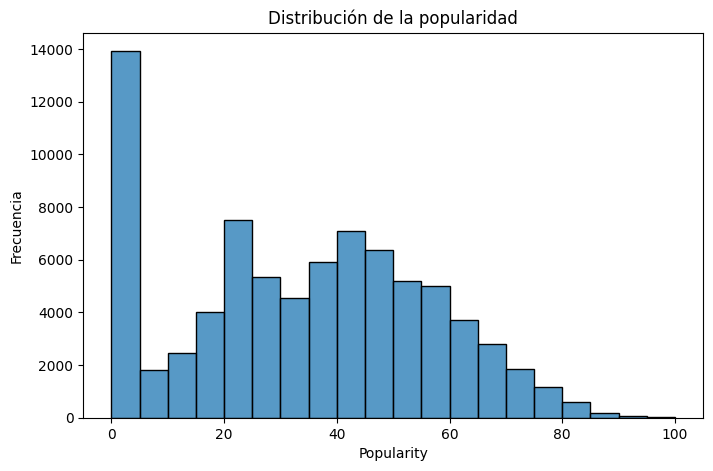

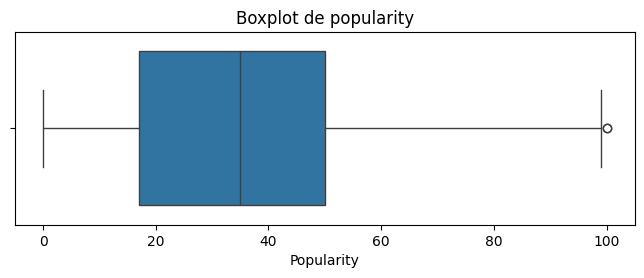

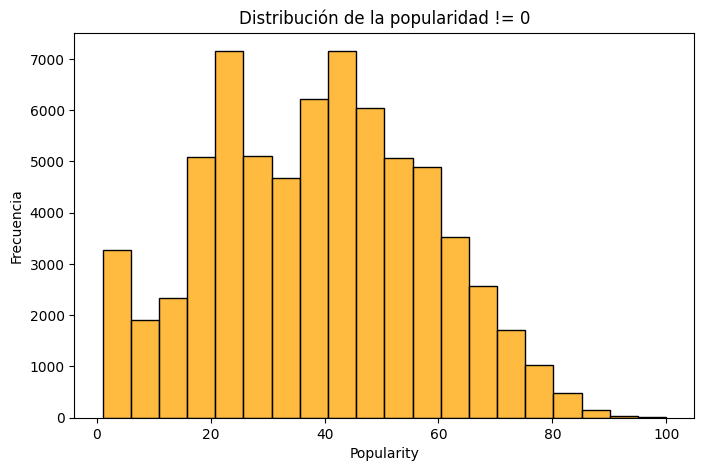

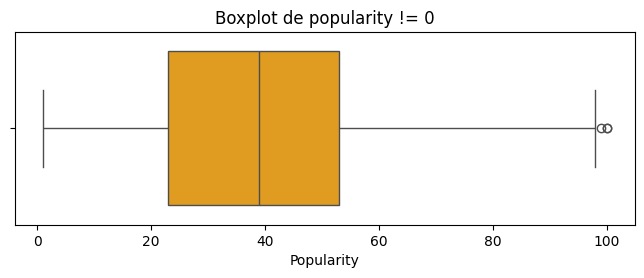


Cantidad de canciones con popularity = 0:
11066

Cantidad de canciones con popularity >= 90:
78


In [16]:
# Histograma
plt.figure(figsize=(8,5))
sns.histplot(df_model["popularity"], bins=20)
plt.title("Distribución de la popularidad")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8,2.5))
sns.boxplot(x=df_model["popularity"])
plt.title("Boxplot de popularity")
plt.xlabel("Popularity")
plt.show()

# Histograma 2
plt.figure(figsize=(8,5))
sns.histplot(df_model["popularity"][df_model["popularity"] != 0], bins=20, color="orange")
plt.title("Distribución de la popularidad != 0")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure(figsize=(8,2.5))
sns.boxplot(x=df_model["popularity"][df_model["popularity"] != 0], color="orange")
plt.title("Boxplot de popularity != 0")
plt.xlabel("Popularity")
plt.show()

# Conteo de valores extremos
print("\nCantidad de canciones con popularity = 0:")
print((df_model["popularity"] == 0).sum())

print("\nCantidad de canciones con popularity >= 90:")
print((df_model["popularity"] >= 90).sum())

La variable popularity presenta una distribución particular caracterizada por una alta concentración de canciones con valores cercanos a cero, junto con un comportamiento más continuo en el resto de los datos. Esto sugiere la existencia de dos dinámicas dentro del dataset: un grupo amplio de canciones con baja o nula exposición, y otro grupo con distintos niveles de popularidad. Esta estructura no corresponde a una distribución completamente uniforme ni típicamente sesgada, sino a una combinación de ambos comportamientos.

Al analizar únicamente las canciones con popularidad mayor a cero, la distribución se vuelve más regular, mostrando una mayor concentración en niveles bajos y medios, y una disminución progresiva hacia valores altos. Esto indica que, incluso entre canciones con cierta visibilidad, alcanzar altos niveles de popularidad es menos frecuente. En conjunto, estos hallazgos sugieren que la variable objetivo tiene una complejidad inherente que puede influir en el desempeño del modelo, especialmente en la predicción de valores extremos.

## Análisis univariado de variables numéricas
*  Distribución de cada variable
*  Identificación de outliers
*  Rangos y escalas
*  Detección de variables con baja variabilidad

In [17]:
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [col for col in num_cols if col != "popularity"]
# Key, mode, time_signature son vbles categóricas con valores numéricos
num_cols = [col for col in num_cols if col not in ["key", "mode", "time_signature"]]
num_cols

['duration_ms',
 'danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo']

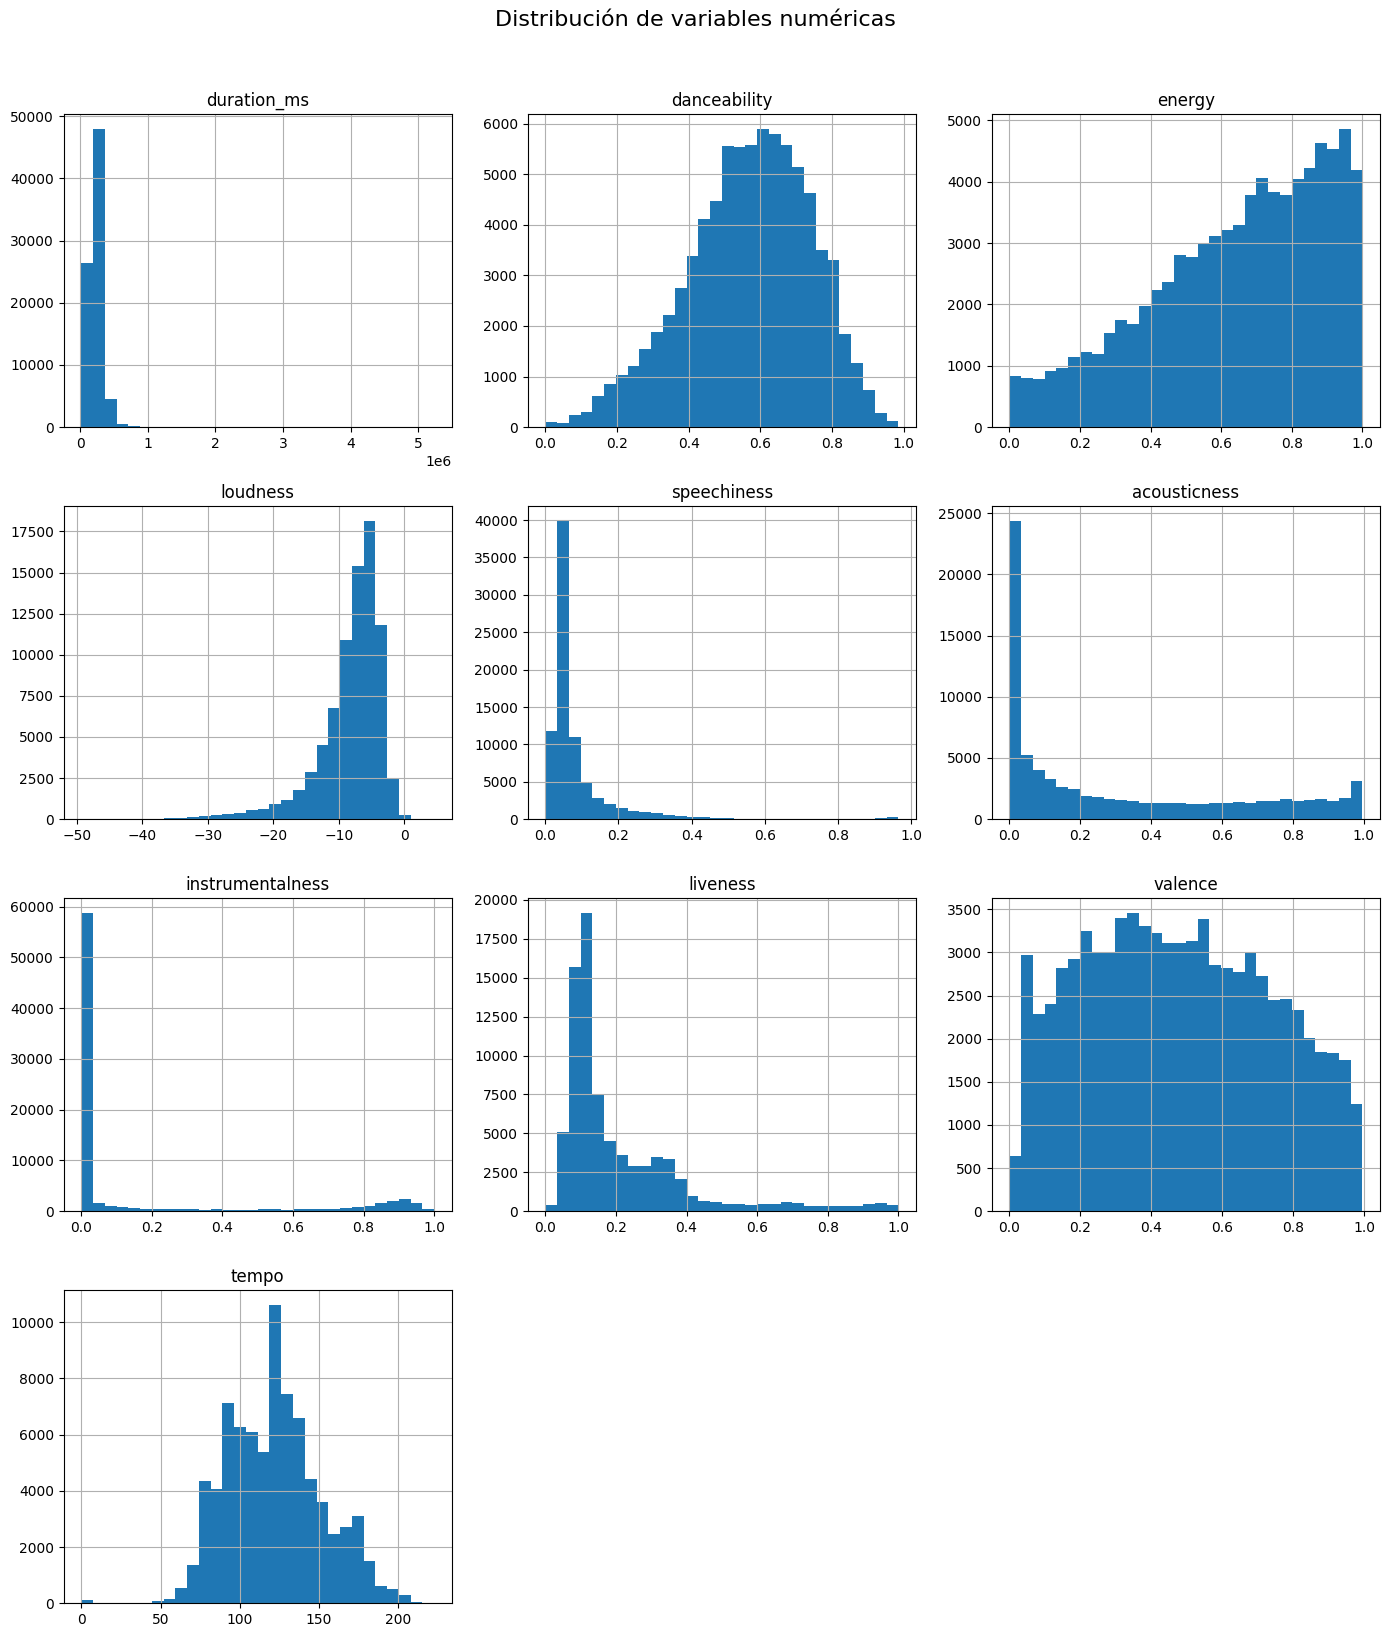

In [18]:
# Histogramas
n_cols = 3
n_rows = len(num_cols) // n_cols + int(len(num_cols) % n_cols != 0)

df_model[num_cols].hist(bins=30, figsize=(14, 4*n_rows), layout=(n_rows, n_cols))

plt.suptitle("Distribución de variables numéricas", y=1.02, size=16)
plt.tight_layout()
plt.show()

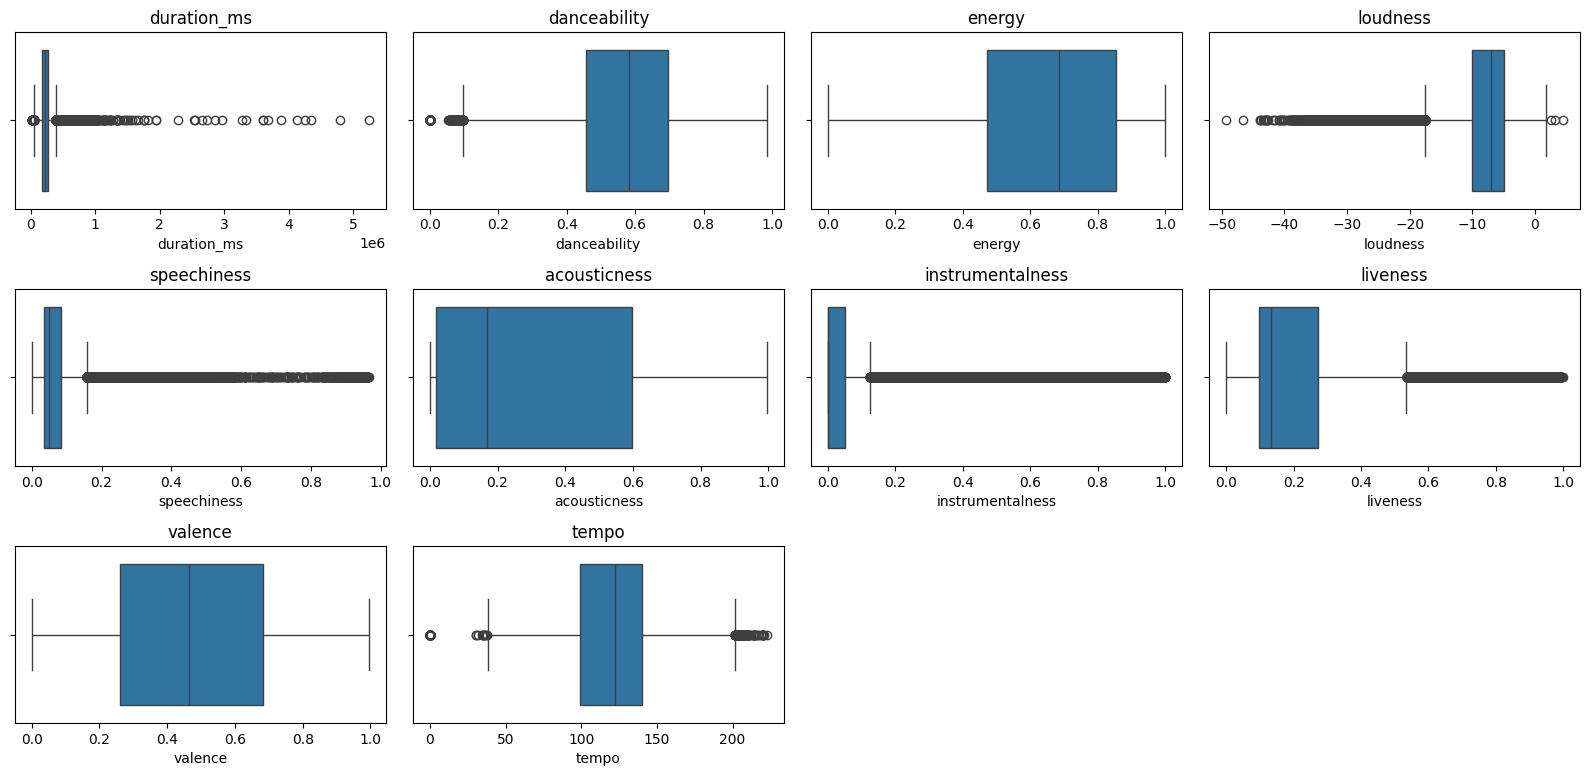

In [19]:
# Boxplots

plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df_model[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
desc = df_model[num_cols].describe().T
desc["range"] = desc["max"] - desc["min"]
desc["IQR"] = desc["75%"] - desc["25%"]

desc.round(2)

,count,mean,std,min,25%,50%,75%,max,range,IQR
duration_ms,79497.0,227960.76,103862.90,13386.00,174545.00,212903.00,261543.00,5237295.00,5223909.00,86998.00
danceability,79497.0,0.57,0.17,0.00,0.46,0.58,0.70,0.98,0.98,0.24
energy,79497.0,0.64,0.25,0.00,0.47,0.69,0.85,1.00,1.00,0.38
loudness,79497.0,-8.25,5.02,-49.31,-9.99,-7.01,-5.00,4.53,53.84,5.00
speechiness,79497.0,0.08,0.11,0.00,0.04,0.05,0.08,0.96,0.96,0.05
acousticness,79497.0,0.31,0.33,0.00,0.02,0.17,0.60,1.00,1.00,0.58
instrumentalness,79497.0,0.16,0.31,0.00,0.00,0.00,0.05,1.00,1.00,0.05
liveness,79497.0,0.21,0.19,0.00,0.10,0.13,0.27,1.00,1.00,0.18
valence,79497.0,0.47,0.26,0.00,0.26,0.46,0.68,1.00,1.00,0.42
tempo,79497.0,122.10,29.93,0.00,99.14,122.01,140.05,222.60,222.60,40.92


Las variables numéricas presentan comportamientos heterogéneos en términos de distribución, dispersión y presencia de valores extremos. Se identifican tres grandes tipos de comportamiento: distribuciones aproximadamente normales, distribuciones altamente sesgadas y variables discretas.

En primer lugar, variables como danceability, energy, valence y en menor medida tempo muestran distribuciones relativamente balanceadas, concentradas en rangos medios, lo que sugiere una buena variabilidad y potencial capacidad predictiva. En contraste, variables como speechiness, instrumentalness, liveness y acousticness presentan distribuciones altamente sesgadas hacia valores cercanos a cero, indicando que la mayoría de las canciones tienen niveles bajos en estas características, con pocos casos extremos.

Por otro lado, se observa la presencia de outliers en variables como duration_ms, loudness y tempo. En el caso de duration_ms, se identifican valores extremadamente altos que podrían corresponder a canciones inusualmente largas o posibles inconsistencias en los datos. Sin embargo, en variables como tempo y loudness, los valores extremos parecen coherentes con la naturaleza del dominio musical, por lo que no necesariamente deben ser eliminados de forma inmediata.

No se identifican variables con variabilidad extremadamente baja que deban ser descartadas de inmediato, aunque algunas variables altamente concentradas en valores cercanos a cero podrían aportar menor capacidad predictiva y requerir evaluación adicional en fases posteriores del análisis.

## Análisis univariado de variables categóricas
*  Frecuencia de categorías
*  Identificación de categorías dominantes
*  Cardinalidad de variables

In [21]:
cat_cols = df_model.columns.difference(num_cols+["popularity"]).tolist()

In [22]:
for col in cat_cols:
    print(f"{col}: {df_model[col].nunique()} categorías")

album_name: 37315 categorías
artists: 25775 categorías
explicit: 2 categorías
key: 12 categorías
mode: 2 categorías
time_signature: 5 categorías
track_genre: 114 categorías
track_name: 55767 categorías


In [23]:
# Descartamos variables con alta cardinalidad ya que no van a aportar al modelo
df_model = df_model.drop(columns=["album_name", "artists", "track_name"])
cat_cols = df_model.columns.difference(num_cols+["popularity"]).tolist()
cat_cols

['explicit', 'key', 'mode', 'time_signature', 'track_genre']

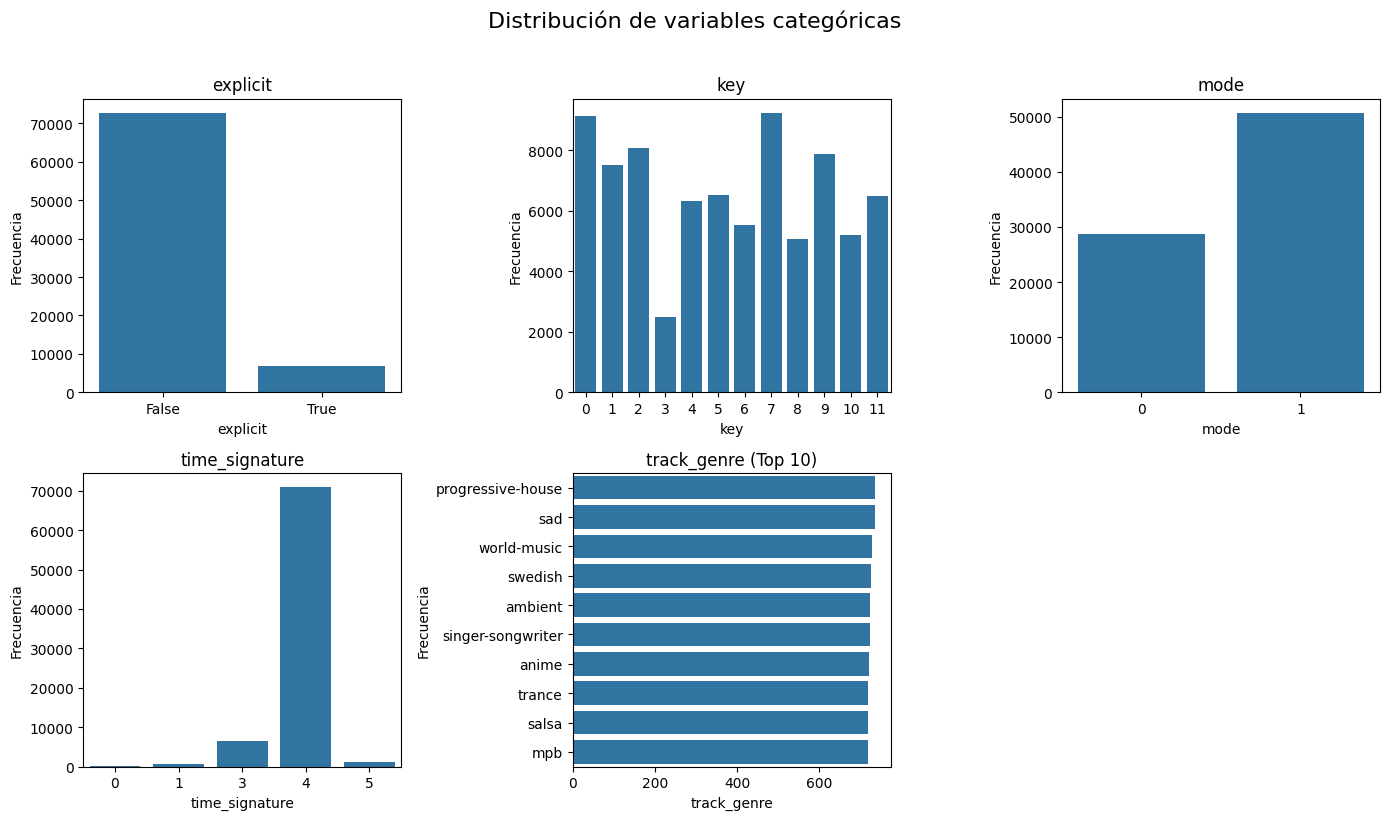

In [24]:
n_cols = 3
n_rows = len(cat_cols) // n_cols + int(len(cat_cols) % n_cols != 0)

plt.figure(figsize=(14, 4*n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    if df_model[col].nunique() > 15:
        top_n = 10
        data = df_model[col].value_counts().head(top_n)
        sns.barplot(x=data.values, y=data.index)
        plt.title(f"{col} (Top {top_n})")
    else:
        sns.countplot(data=df_model, x=col)
        plt.title(col)

    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.suptitle("Distribución de variables categóricas", y=1.02, size=16)
plt.tight_layout()
plt.show()

Las variables categóricas presentan distintos niveles de distribución y balance, lo que tiene implicaciones directas en su uso dentro del modelo.

En primer lugar, la variable explicit muestra un claro desbalance, con una gran mayoría de canciones clasificadas como no explícitas. Esto sugiere que el contenido explícito representa una minoría dentro del dataset, por lo que su impacto en el modelo podría ser limitado o sesgado hacia la categoría dominante. De forma similar, la variable mode presenta una distribución binaria donde predomina el valor correspondiente al modo mayor, lo cual es consistente con la música comercial y podría tener cierto valor explicativo.

Por otro lado, la variable time_signature está fuertemente concentrada en el valor 4, lo que indica una baja variabilidad y refleja la estructura rítmica más común en la música popular. Esto sugiere que su capacidad predictiva podría ser limitada. En contraste, la variable key presenta una distribución más uniforme entre sus categorías, lo que indica mayor diversidad tonal en el dataset y potencial para aportar información al modelo.

Finalmente, la variable track_genre, incluso al observar solo las categorías más frecuentes, no muestra una dominancia extrema de un único género, sino una distribución relativamente balanceada entre varios géneros. Esto sugiere que el género podría ser una variable relevante para capturar diferencias en la popularidad de las canciones, aunque su alta cardinalidad requerirá un tratamiento adecuado en el modelado.

## Análisis bivariado (variables vs popularity)
*  Relación entre variables numéricas y popularity
*  Comparación de popularity por categorías
*  Detección de patrones y tendencias

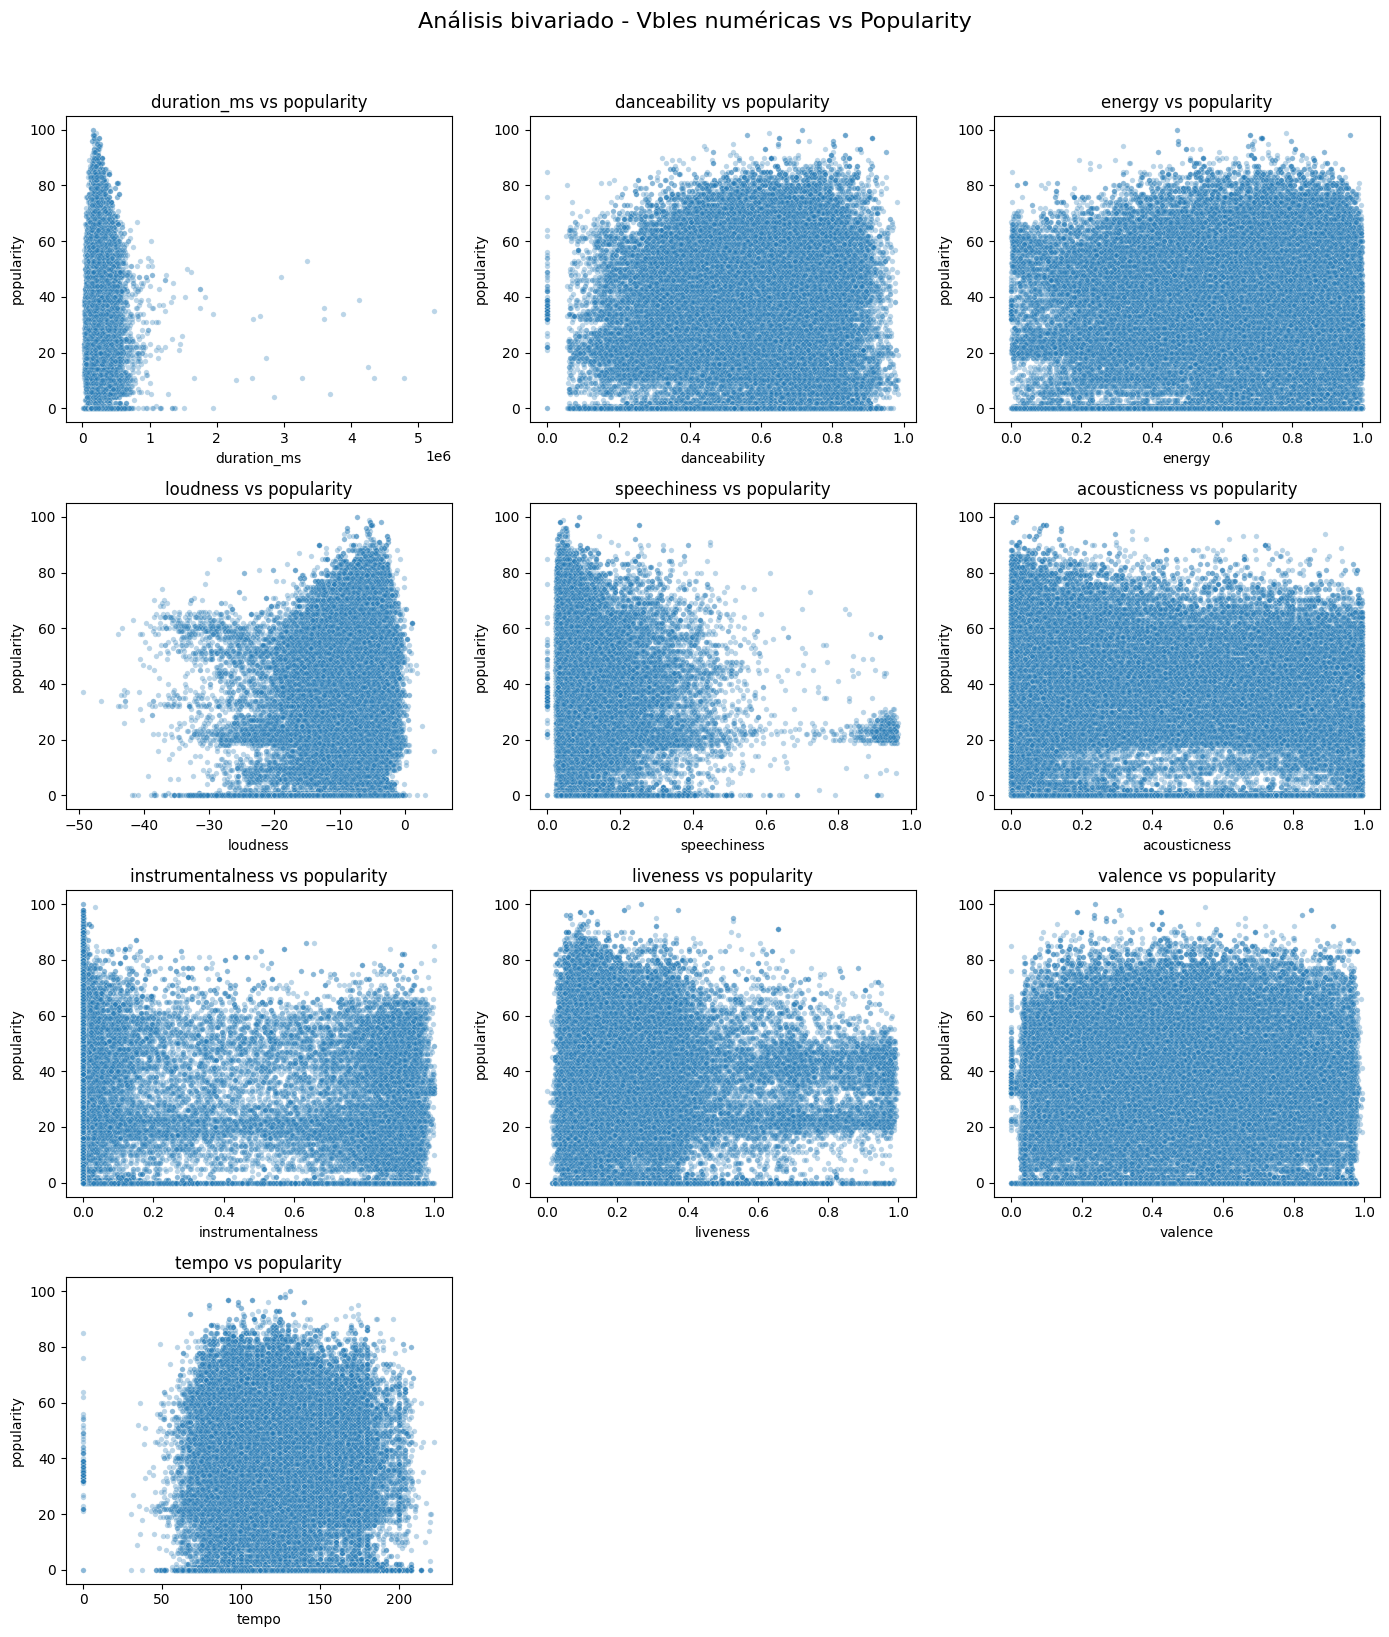

In [25]:
target = "popularity"

# Variables numéricas

n_cols = 3
n_rows = len(num_cols) // n_cols + int(len(num_cols) % n_cols != 0)

plt.figure(figsize=(14, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(data=df_model, x=col, y=target, alpha=0.3, s=15)
    plt.title(f"{col} vs {target}")

plt.suptitle("Análisis bivariado - Vbles numéricas vs Popularity", y=1.02, size=16)
plt.tight_layout()
plt.savefig("scatterplot.png")
plt.show()

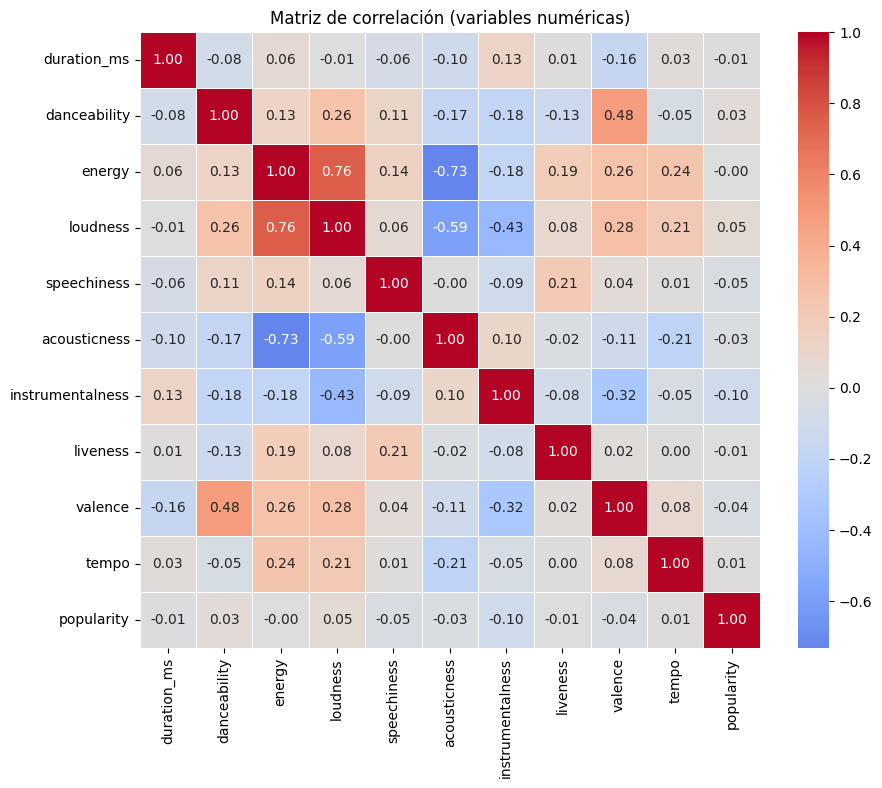

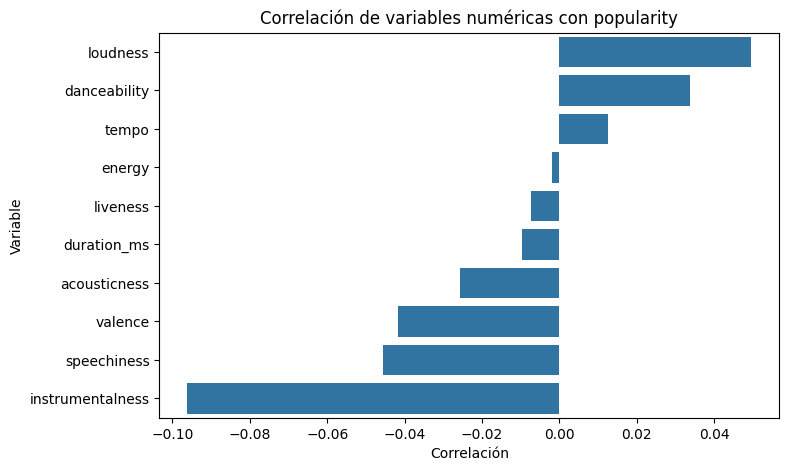

In [26]:
# Correlación con target
cols_corr = num_cols + [target]
corr_matrix = df_model[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación (variables numéricas)")
plt.savefig("cmatrix.png")
plt.show()

corr_target = corr_matrix[target].sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=corr_target.drop(target).values, y=corr_target.drop(target).index)
plt.title("Correlación de variables numéricas con popularity")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

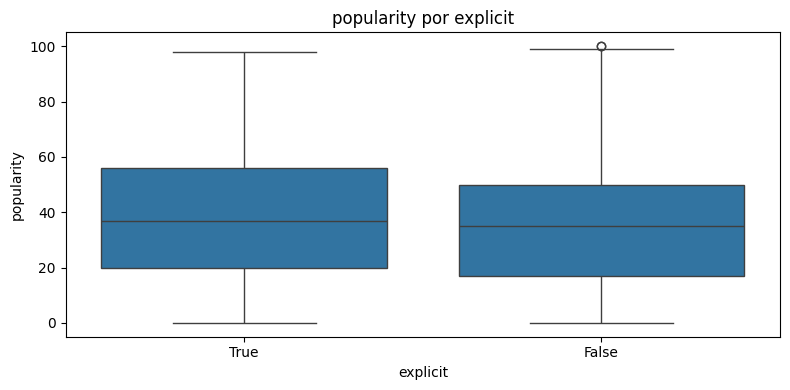

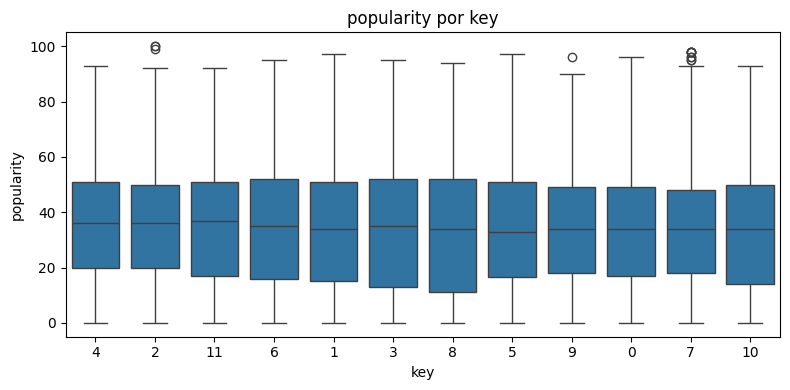

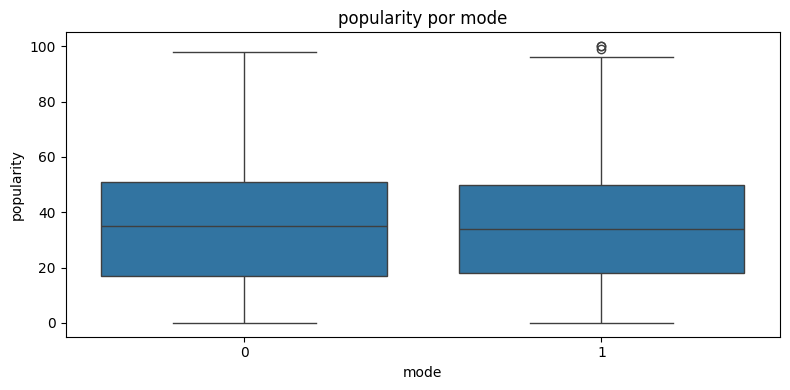

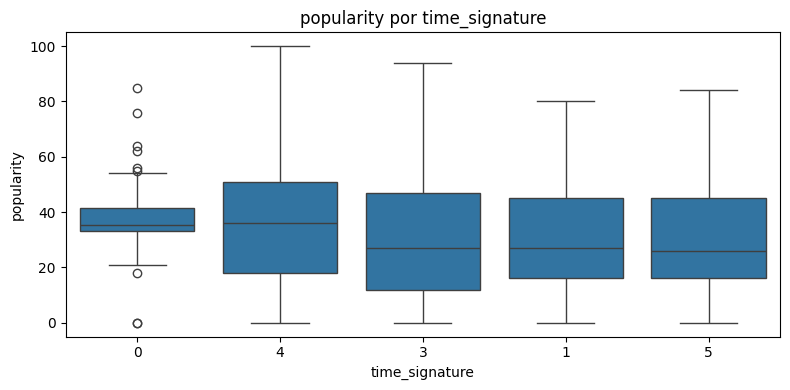

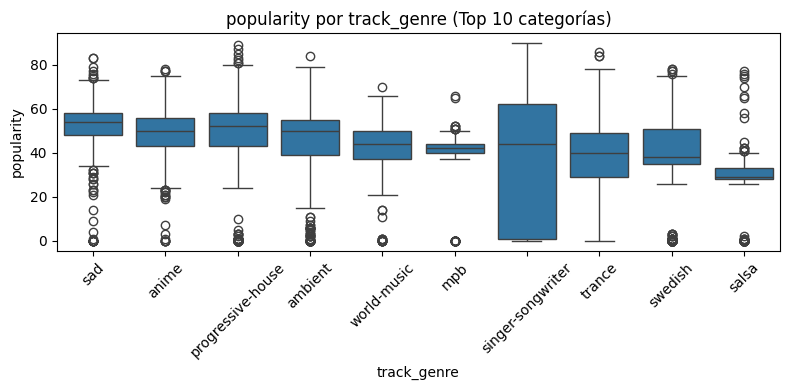

In [27]:
# Comparación de popularity por categorías

for col in cat_cols:
    plt.figure(figsize=(8, 4))

    if col == "track_genre":
        # Top 10 categorías por frecuencia
        top_categories = df_model[col].value_counts().head(10).index
        data_plot = df_model[df_model[col].isin(top_categories)]
        order = data_plot.groupby(col)[target].mean().sort_values(ascending=False).index

        sns.boxplot(data=data_plot, x=col, y=target, order=order)
        plt.xticks(rotation=45)
        plt.title(f"{target} por {col} (Top 10 categorías)")
    else:
        order = df_model.groupby(col)[target].mean().sort_values(ascending=False).index
        sns.boxplot(data=df_model, x=col, y=target, order=order)
        plt.title(f"{target} por {col}")

    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.savefig(f"{col}.png")
    plt.show()

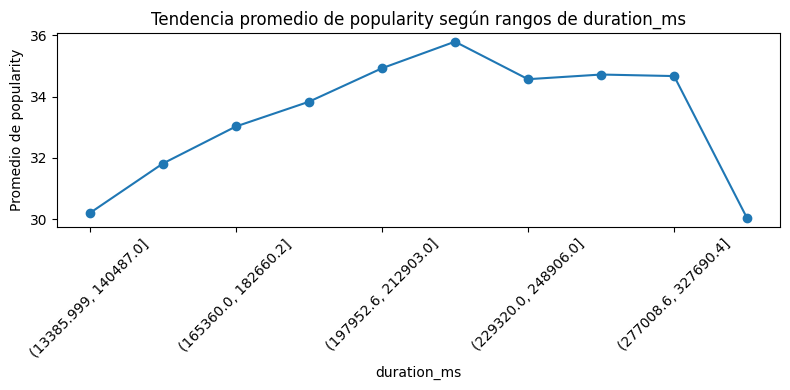

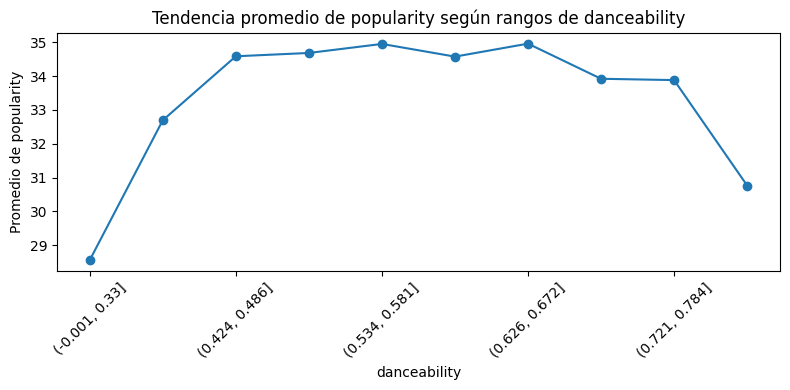

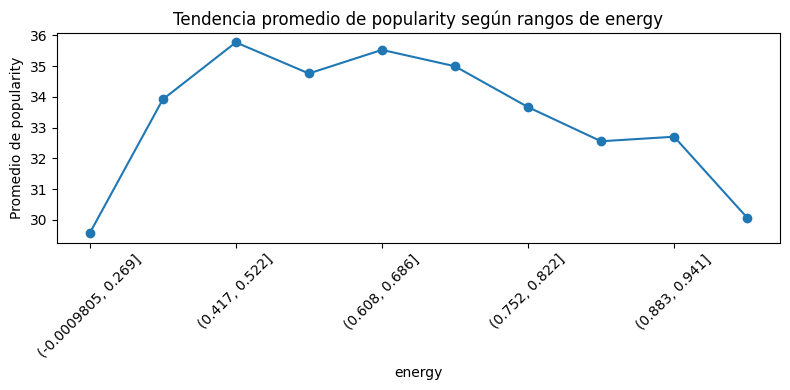

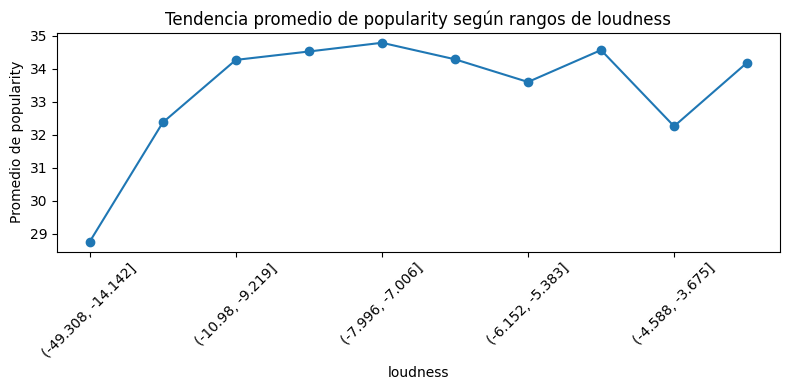

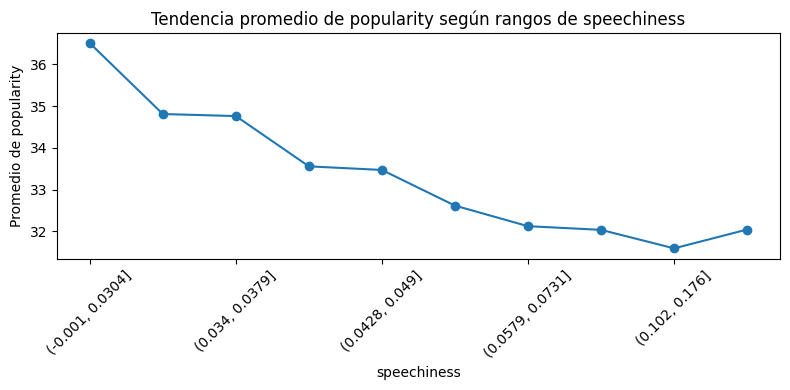

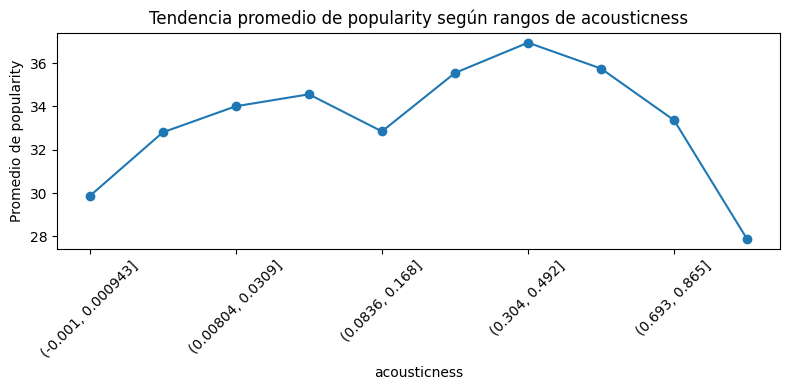

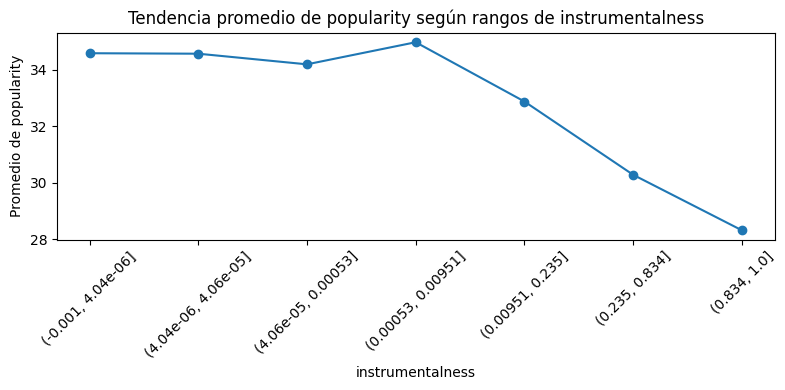

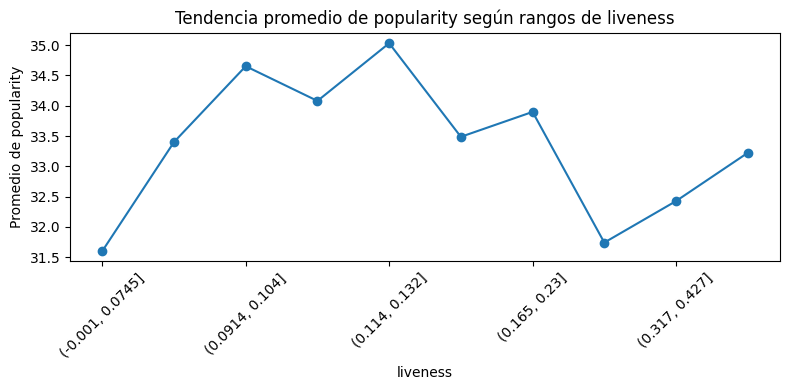

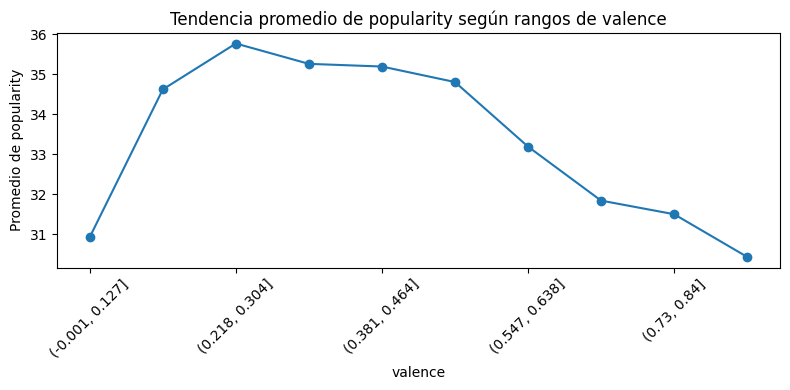

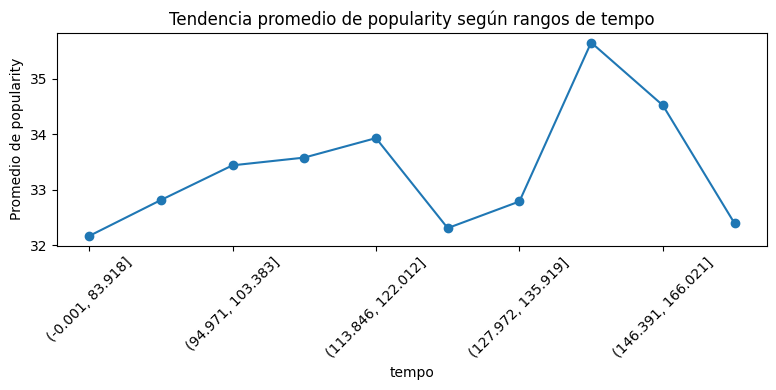

In [28]:
# Tendencias con medias por bins (opcional)

# Esto ayuda a ver patrones más limpios en variables numéricas
num_cols_trend = num_cols.copy()

for col in num_cols_trend:
    temp = df_model[[col, target]].dropna().copy()
    temp["bin"] = pd.qcut(temp[col], q=10, duplicates="drop")
    trend = temp.groupby("bin")[target].mean()

    plt.figure(figsize=(8, 4))
    trend.plot(marker="o")
    plt.title(f"Tendencia promedio de {target} según rangos de {col}")
    plt.xlabel(col)
    plt.ylabel(f"Promedio de {target}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

La popularidad de las canciones no presenta relaciones lineales fuertes con las variables numéricas analizadas, lo que sugiere que el fenómeno es complejo y probablemente depende de interacciones no lineales entre múltiples características. Las variables categóricas, particularmente el género musical, parecen capturar mejor las diferencias en popularidad, mientras que variables como time_signature, mode y key muestran una capacidad explicativa limitada.

El análisis bivariado evidencia que la variable popularity no presenta relaciones lineales fuertes con las variables numéricas disponibles. Los gráficos de dispersión muestran una alta variabilidad y ausencia de patrones claros, lo cual es consistente con los resultados de la matriz de correlación, donde los coeficientes son cercanos a cero. Esto sugiere que la popularidad de una canción no depende de una única característica acústica, sino de combinaciones más complejas de variables y posiblemente de factores externos no incluidos en el dataset.

Por otro lado, las variables categóricas muestran un comportamiento diferenciado. En particular, el género musical (track_genre) evidencia variaciones en los niveles de popularidad, lo que indica que puede capturar diferencias relevantes entre canciones. En contraste, variables como explicit, mode, key y time_signature no presentan diferencias significativas en la distribución de la popularidad, lo que limita su capacidad explicativa individual. En conjunto, estos resultados sugieren que el problema requiere modelos capaces de capturar relaciones no lineales e interacciones entre variables.

# Preprocesamiento de los datos

Se utilizan técnicas de transformación de variables. Se crea una función para generar transformaciones de las variables originales con el fin de mejorar el rendimiento del modelo.

In [29]:
# Transformación vbles categoricas
df_model = pd.get_dummies(df_model, columns=["track_genre", "key", "time_signature"], drop_first=True)

# Descartar registros con popularity igual a cero
df_model = df_model[df_model["popularity"] != 0]

In [30]:
def transformations(X):
  X_ = X.copy()

  # Crear combinaciones de vbles
  X_["energy_danceability"] = X_["energy"] * X_["danceability"]
  X_["energy_loudness"] = X_["energy"] * X_["loudness"]
  X_["valence_energy"] = X_["valence"] * X_["energy"]

  # Reducir impacto de outliers
  X_["log_duration"] = np.log1p(X_["duration_ms"])
  X_["log_tempo"] = np.log1p(X_["tempo"])

  # Thresholds: Convierten señales débiles en decisiones claras
  X_["is_acoustic"] = (X_["acousticness"] > 0.5).astype(int)
  X_["is_high_energy"] = (X_["energy"] > 0.7).astype(int)
  X_["is_danceable"] = (X_["danceability"] > 0.7).astype(int)

  return X_

# Split Train/Test

In [31]:
from sklearn.model_selection import train_test_split
# Partición de datos en X, y
X = df_model.drop(columns=[target])
y = df_model[target]

#Partición en Train y Test
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=0)

In [32]:
transformations(XTrain)

,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,time_signature_4,time_signature_5,energy_danceability,energy_loudness,valence_energy,log_duration,log_tempo,is_acoustic,is_high_energy,is_danceable
26875,129080,False,0.717,0.328,-13.710,1,0.0367,0.9600,0.000222,0.1300,...,True,False,0.235176,-4.496880,0.274208,11.768195,4.730233,1,0,1
4205,245613,False,0.715,0.218,-17.547,0,0.0396,0.7090,0.925000,0.0820,...,True,False,0.155870,-3.825246,0.017484,12.411516,4.709458,1,0,1
6786,115578,False,0.399,0.136,-20.219,1,0.0307,0.9850,0.895000,0.1560,...,False,False,0.054264,-2.749784,0.053856,11.657710,4.617049,1,0,0
7732,276000,False,0.257,0.512,-6.828,0,0.0372,0.2810,0.000033,0.1060,...,False,False,0.131584,-3.495936,0.041318,12.528160,4.517540,0,0,0
59782,198426,False,0.546,0.864,-1.314,1,0.0293,0.1420,0.000000,0.8250,...,True,False,0.471744,-1.135296,0.462240,12.198177,5.015855,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24800,207000,False,0.566,0.781,-6.963,1,0.0302,0.3760,0.091600,0.0967,...,True,False,0.442046,-5.438103,0.751322,12.240479,4.900165,0,1,0
53545,231800,False,0.614,0.839,-6.931,1,0.0412,0.0027,0.000107,0.0942,...,True,False,0.515146,-5.815109,0.419500,12.353635,5.017247,0,1,0
49732,180237,False,0.683,0.898,-0.889,1,0.0340,0.4520,0.002180,0.0706,...,True,False,0.613334,-0.798322,0.447204,12.102033,4.889981,0,1,0
50855,229394,False,0.444,0.637,-3.730,0,0.0361,0.1700,0.000000,0.1120,...,True,False,0.282828,-2.376010,0.146510,12.343201,4.392237,0,0,0


In [33]:
from sklearn.preprocessing import StandardScaler

def scale_data(XTr, XTs):
  scaler = StandardScaler()
  XTrain_scaled = scaler.fit_transform(XTr)
  XTest_scaled = scaler.transform(XTs)
  return XTrain_scaled, XTest_scaled

# Selección de variables

In [34]:
# from sklearn.ensemble import RandomForestRegressor

# # Entrenar modelo
# rf = RandomForestRegressor(n_estimators=100, random_state=42)
# X_ = transformations(X)
# rf.fit(X_, y)

# # Importancia de variables
# rf_importance = pd.Series(rf.feature_importances_, index=X_.columns)
# rf_importance = rf_importance.sort_values(ascending=False)

# rf_importance.head(20)

In [35]:
# # Importancia de variables
# rf_importance = pd.Series(rf.feature_importances_, index=X_.columns)
# rf_importance = rf_importance.sort_values(ascending=False)

# rf_importance.head(20)

In [36]:
# from sklearn.inspection import permutation_importance

# perm = permutation_importance(
#     rf,
#     X,
#     y,
#     n_repeats=5,
#     random_state=42
# )

# perm_importance = pd.Series(perm.importances_mean, index=X.columns)
# perm_importance = perm_importance.sort_values(ascending=False)

# perm_importance.head(20)

# Evaluación de modelos

In [38]:
from sklearn.model_selection import cross_val_score, KFold

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Modelos
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )
}

# Evaluación
results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse_scores = -scores

    results.append({
        "Model": name,
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std()
    })
    print(f"Modelo {name} finalizado.")

results_df = pd.DataFrame(results).sort_values(by="RMSE_mean")

results_df

Modelo RandomForest finalizado.
Modelo GradientBoosting finalizado.
Modelo XGBoost finalizado.


,Model,RMSE_mean,RMSE_std
0,RandomForest,13.932656,0.029852
2,XGBoost,14.726232,0.095415
1,GradientBoosting,16.344356,0.085944


Escogemos el modelo Random Forest por tener el menor RMSE.

# Selección y calibración del modelo

In [ ]:
from sklearn.model_selection import cross_val_score

estimator_range = range(50, 210, 50)

rmse_scores = []
estimators_used = []

tolerance = 0.01

for estimator in estimator_range:

    model_RF_ = RandomForestRegressor(
        n_estimators=estimator,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model_RF_,
        XTrain,
        yTrain,
        cv=5,
        scoring='neg_root_mean_squared_error'
    ).mean()

    rmse = -score  # convertir a positivo

    rmse_scores.append(rmse)
    estimators_used.append(estimator)

    print(f"Modelo con {estimator} estimators finalizado. RMSE: {rmse:.4f}")

    # Early stopping: no mejora vs los dos anteriores
    if len(rmse_scores) >= 3:
        if (rmse_scores[-1] > rmse_scores[-2] - tolerance and
            rmse_scores[-1] > rmse_scores[-3] - tolerance):

            print("Early stopping activado")
            break

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(estimators_used, rmse_scores, marker='o')

# marcar mejor punto
best_idx = rmse_scores.index(min(rmse_scores))
plt.scatter(estimators_used[best_idx], rmse_scores[best_idx], color='red', label='Mejor')

# agregar valores
for x, y in zip(estimators_used, rmse_scores):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('Calibración de RF: RMSE vs. n_estimators')
plt.legend()
plt.grid()

plt.show()

Modelo con 50 estimators finalizado. RMSE: 14.2677
Modelo con 100 estimators finalizado. RMSE: 14.1788


In [ ]:
# max_features
feature_range = range(1, XTrain.shape[1] + 1)
rmse_scores = []
features_used = []

tolerance = 0.01

for feature in feature_range:
    model_RF_ = RandomForestRegressor(
        n_estimators=100,
        max_features=feature,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model_RF_,
        XTrain,
        yTrain,
        cv=5,
        scoring='neg_root_mean_squared_error'
    ).mean()

    rmse = -score  # convertir a positivo
    rmse_scores.append(rmse)
    features_used.append(feature)

    print(f"Modelo con {feature} finalizado. RMSE: {rmse:.4f}")

    # condición de parada
    if len(rmse_scores) >= 3:
        if (rmse_scores[-1] > rmse_scores[-2] - tolerance and
            rmse_scores[-1] > rmse_scores[-3]- tolerance):

            print("Early stopping activado")
            break

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(features_used, rmse_scores, marker='o')

# marcar mejor punto
best_idx = rmse_scores.index(min(rmse_scores))
plt.scatter(features_used[best_idx], rmse_scores[best_idx], color='red', label='Mejor')

# agregar valores
for x, y in zip(features_used, rmse_scores):
    plt.text(x, y, f"{y:.2f}", ha='center', va='bottom')

plt.xlabel('max_features')
plt.ylabel('RMSE')
plt.title('Calibración de RF: RMSE vs. n_estimators')
plt.legend()
plt.grid()

plt.show()

# Calibración del modelo

# Predicciones para la competencia